# Geometric Transformations and Symmetry Groups
## From Euclidean Motions to Möbius Transformations

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eduenez/courses/blob/main/2026fall/mat4233/downloads/public/activities/geometric-transformations.ipynb)
[![License: CC BY 4.0](https://img.shields.io/badge/License-CC%20BY%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by/4.0/)

---

Symmetry in geometry is captured beautifully by the concept of a **transformation group**.
This notebook allows you to explore geometric transformations in the plane and beyond.

1. **Euclidean and Affine Motions** — rigid motions (translations, rotations, reflections), similitudes, and affine transformations of the plane.
2. **Discrete vs. Continuous Orbits** — how groups act on points: discrete (like dihedral or cyclic groups) vs. continuous 1-parameter subgroups (tracing out lines and curves).
3. **Möbius Transformations** — conformal maps of the extended plane $\mathbb{C} \cup \{\infty\}$, revealing the structure of the projective space $\mathbb{C}\mathbb{P}^1$.
4. **The Riemann Sphere** — stereographic projection to visualize elliptic, hyperbolic, and loxodromic transformations intuitively.
5. **A Glimpse of 3D (Optional)** — exploring similar concepts extending into three dimensions.

Nothing here has a grade attached and there's nothing to submit. Tinker freely — *Runtime → Run all* always resets you to a clean state.



---
# 0. Setup


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_points(pts, c='b', marker='o', ax=None, title=None, aspect='equal'):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,6))
    ax.scatter(pts.real, pts.imag, c=c, marker=marker)
    if aspect == 'equal':
        ax.set_aspect('equal', adjustable='box')
    if title:
        ax.set_title(title)
    ax.grid(True)
    return ax


---
# 1. Rigid Motions of the Plane

A rigid motion (isometry) preserves distances. They are generated by translations, rotations, and reflections.
In the complex plane, a transformation $f(z)$ is a rigid motion if it can be written as:
$$f(z) = e^{i\theta} z + b \quad \text{(orientation preserving)}$$
or
$$f(z) = e^{i\theta} \overline{z} + b \quad \text{(orientation reversing)}$$

Let's see them in action.


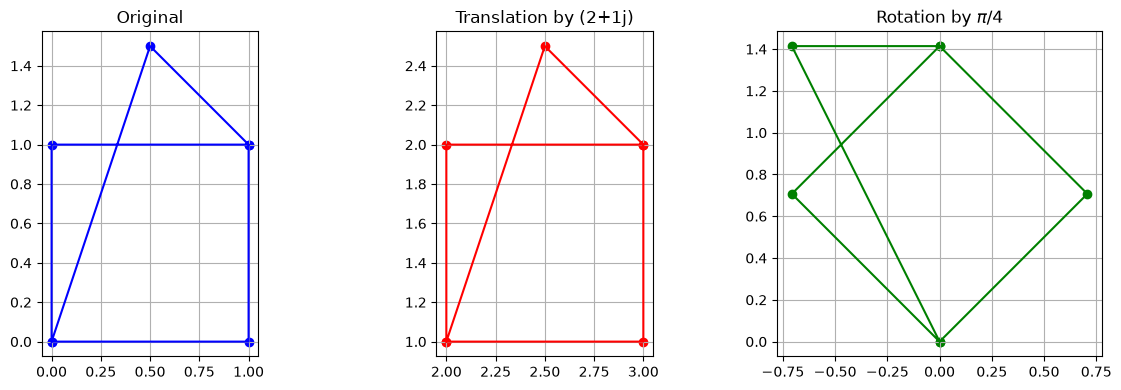

In [2]:
# A simple shape
shape = np.array([0, 1, 1+1j, 1j, 0, 0.5+1.5j, 1+1j])

plt.figure(figsize=(12, 4))
ax1 = plt.subplot(131)
plot_points(shape, marker='o', ax=ax1, title="Original")
ax1.plot(shape.real, shape.imag, c='b')

# Translation
b = 2 + 1j
translated = shape + b
ax2 = plt.subplot(132)
plot_points(translated, c='r', marker='o', ax=ax2, title=f"Translation by {b}")
ax2.plot(translated.real, translated.imag, c='r')

# Rotation
theta = np.pi / 4
rotated = np.exp(1j * theta) * shape
ax3 = plt.subplot(133)
plot_points(rotated, c='g', marker='o', ax=ax3, title=fr"Rotation by $\pi/4$")
ax3.plot(rotated.real, rotated.imag, c='g')

plt.tight_layout()
plt.show()


---
# 2. Orbits of a Group Action

A group action captures how a group moves points around. The **orbit** of a point is the set of all places it can be moved to.
Let's look at the orbit of a cyclic group of rational rotations (finite) versus an infinite cyclic group of iterates of a rigid motion.


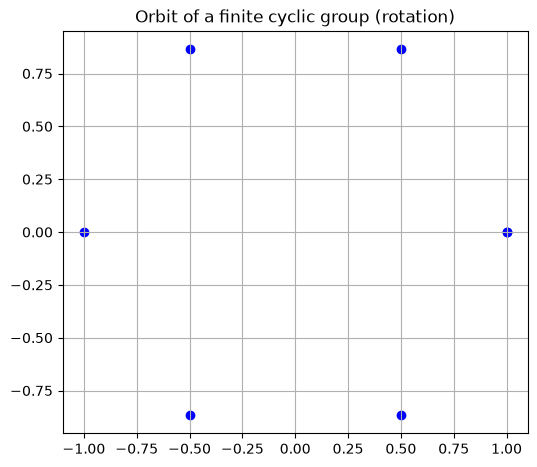

<Figure size 640x480 with 0 Axes>

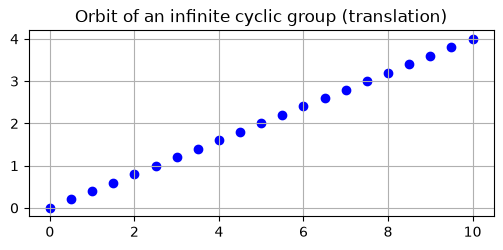

In [3]:
def plot_orbit(z0, generator, max_iters=20, title="Orbit"):
    pts = [z0]
    for _ in range(max_iters):
        pts.append(generator(pts[-1]))
    pts = np.array(pts)
    plot_points(pts, title=title)

# Orbit under a rotation of order 6
z0 = 1 + 0j
def rot_6(z): return np.exp(2j * np.pi / 6) * z
plot_orbit(z0, rot_6, max_iters=6, title="Orbit of a finite cyclic group (rotation)")

# Orbit under a translation (infinite cyclic)
z0 = 0 + 0j
def trans(z): return z + (0.5 + 0.2j)
plt.figure()
plot_orbit(z0, trans, max_iters=20, title="Orbit of an infinite cyclic group (translation)")
plt.show()


# Continuous (1-parameter) Subgroups

If instead of hopping discretely we flow continuously (e.g., $f_t(z) = z + t \cdot v$ for real $t$), the orbit becomes a 1-dimensional curve.


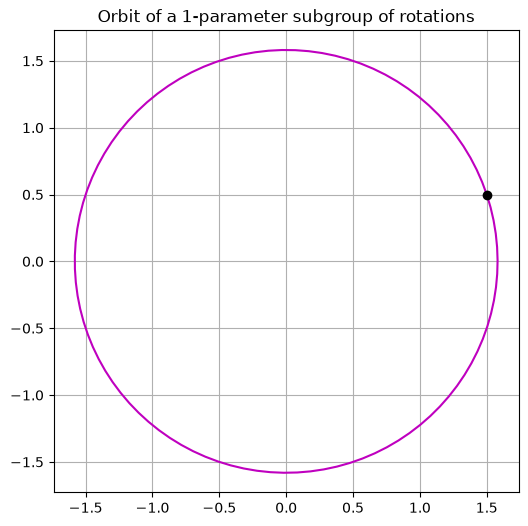

In [4]:
# A 1-parameter subgroup of rotations: f_t(z) = exp(i*t) * z
t_vals = np.linspace(0, 2*np.pi, 100)
z0 = 1.5 + 0.5j
orbit_curve = z0 * np.exp(1j * t_vals)

plt.figure(figsize=(6,6))
plt.plot(orbit_curve.real, orbit_curve.imag, c='m')
plt.scatter([z0.real], [z0.imag], c='k', zorder=5) # starting point
plt.title("Orbit of a 1-parameter subgroup of rotations")
plt.axis('equal')
plt.grid(True)
plt.show()


---
# 3. Möbius Transformations

A Möbius transformation maps the extended complex plane onto itself:
$$f(z) = \frac{az + b}{cz + d}, \quad ad - bc \neq 0$$
They are the conformal (angle-preserving) bijections of $\mathbb{C} \cup \{\infty\}$.


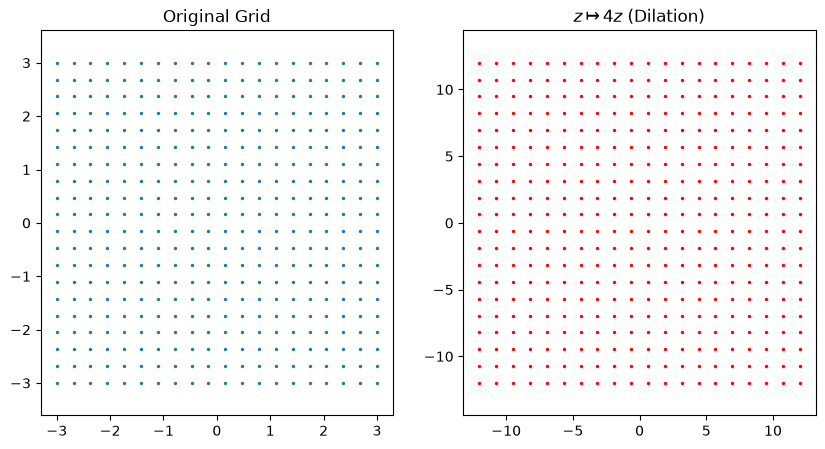

In [5]:
def mobius(z, a, b, c, d):
    # Handle the point at infinity and division by zero loosely for plotting
    with np.errstate(divide='ignore', invalid='ignore'):
        w = (a*z + b)/(c*z + d)
    return w

# Create a grid to see how it transforms
x, y = np.meshgrid(np.linspace(-3, 3, 20), np.linspace(-3, 3, 20))
z_grid = x + 1j*y
z_flat = z_grid.flatten()

# An example Möbius transformation: hyperbolic-like
w_flat = mobius(z_flat, a=2, b=0, c=0, d=0.5)

plt.figure(figsize=(10,5))
plt.subplot(121)
plt.scatter(z_flat.real, z_flat.imag, s=2)
plt.title("Original Grid")
plt.axis('equal')

plt.subplot(122)
plt.scatter(w_flat.real, w_flat.imag, s=2, c='r')
plt.title(r"$z \mapsto 4z$ (Dilation)")
plt.axis('equal')
plt.show()


---
# 4. The Riemann Sphere & Stereographic Projection

Möbius transformations are best seen on the **Riemann Sphere**. Stereographic projection maps the sphere $S^2$ to the plane $\mathbb{C} \cup \{\infty\}$.


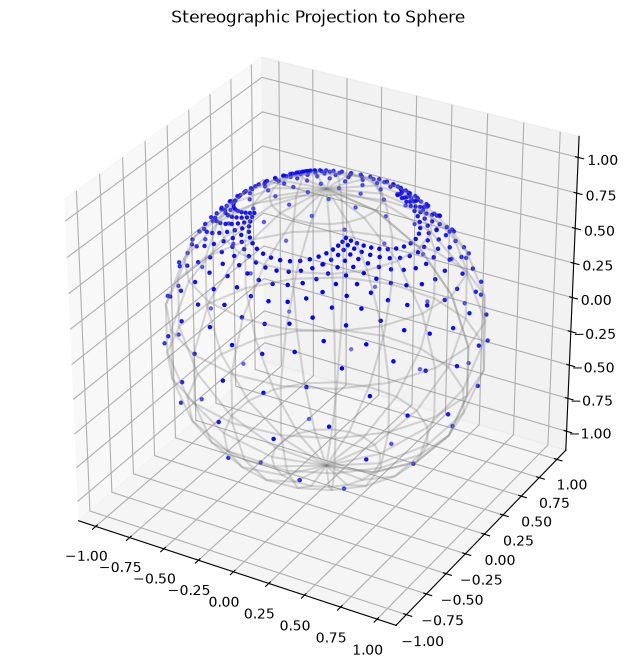

In [6]:
def stereo_project_to_sphere(z):
    # (X, Y, Z) on unit sphere
    X = 2 * z.real / (1 + abs(z)**2)
    Y = 2 * z.imag / (1 + abs(z)**2)
    Z = (abs(z)**2 - 1) / (1 + abs(z)**2)
    return X, Y, Z

X, Y, Z = stereo_project_to_sphere(z_flat)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X, Y, Z, s=5, c='b')
ax.set_title("Stereographic Projection to Sphere")
# Draw a wireframe sphere for reference
u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
xs = np.cos(u)*np.sin(v)
ys = np.sin(u)*np.sin(v)
zs = np.cos(v)
ax.plot_wireframe(xs, ys, zs, color="gray", alpha=0.3)
ax.set_box_aspect([1,1,1])
plt.show()


---
## License

This notebook is released under the [Creative Commons Attribution 4.0
International License (CC BY 4.0)](https://creativecommons.org/licenses/by/4.0/). You are free to copy, adapt,
and redistribute it, including for commercial purposes, provided you give
appropriate credit.

Suggested attribution: *"Geometric Transformations and Symmetry Groups" by [Eduardo Dueñez](https://supernumero.us/about),
licensed under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).*
